# Analysis 2e: Representation Alignment Between Encoders

Measures **Pearson correlation between molecule encoders** — i.e. how closely two
encoders organise the *same* molecules in their respective embedding spaces.

We use **Representational Similarity Analysis (RSA)**:
1. For each encoder, compute the pairwise cosine-similarity matrix over a shared
   set of SMILES.
2. Flatten the upper triangle into a vector.
3. Pearson-correlate those vectors between every pair of encoders.

RSA is invariant to linear isomorphism between the embedding spaces, so it works
across encoders with very different output dimensionalities (PairMixer 512, MolE
1000, KPGT 2304, MiniMol 512).

**Starting set** — PairMixer 12M (toymix pretrain) versus baseline foundation
encoders (MiniMol, MolE, KPGT). Other PairMixer variants are loaded if their
CKA cache exists, so the heatmap auto-grows.

**Prerequisites**
- `python scripts/cka_analysis.py` — caches PairMixer 12M embeddings under
  `results/cka_analysis/embeddings_*.pt`.
- `02d_analysis_sne.ipynb` — caches MiniMol/MolE/KPGT embeddings under
  `results/tsne_admet/baseline_*.pt` (re-extracted on demand if missing).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})
sns.set_style("whitegrid")

EMB_DIR_PM = Path("../results/cka_analysis")        # PairMixer cached embs
EMB_DIR_BL = Path("../results/tsne_admet")          # MiniMol / MolE / KPGT cache
OUT_DIR    = Path("../results/representation_alignment")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPO_ROOT = str(Path("..").resolve())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

## 1. Load encoder embeddings

PairMixer embeddings come from the CKA cache (graph-level head output). Baseline
embeddings are produced by the downstream `MoleculeEncoder` adapters and cached
per-SMILES, so re-runs are cheap.

In [2]:
# PairMixer 12M variants we want to compare. Start with toymix; the others are
# loaded opportunistically (they're already in the CKA cache).
PM_CKPTS = [
    "toymix",
    "toymix_all",
    "toymix_4ds_v2",
    "toymix_dti_esmcv2",
    "toymix_bbbc047",
    "toymix_lpm24_litopenai",
    "largemix",
]
EMB_TYPE = "graph"  # post-pooling MLP output

encoders: dict[str, dict] = {}


def _register(label: str, blob: dict) -> None:
    if EMB_TYPE not in blob:
        return
    smiles = blob["smiles"]
    emb = blob[EMB_TYPE].float().numpy()
    encoders[label] = {
        "emb":   emb,
        "smi2i": {s: i for i, s in enumerate(smiles)},
    }
    print(f"  {label:42s}  emb={emb.shape}")


for name in PM_CKPTS:
    f = EMB_DIR_PM / f"embeddings_{name}.pt"
    if not f.exists():
        print(f"  skip pairmixer:{name} (no cache at {f})")
        continue
    blob = torch.load(f, map_location="cpu", weights_only=False)
    _register(f"pairmixer_12M:{name}", blob)

# Keep only the last legacy `toymix_all` cache here; the multi-epoch
# trajectory is intentionally excluded from this notebook.


  pairmixer_12M:toymix                        emb=(46201, 512)
  pairmixer_12M:toymix_all                    emb=(46201, 512)
  pairmixer_12M:toymix_4ds_v2                 emb=(46201, 512)
  pairmixer_12M:toymix_dti_esmcv2             emb=(46201, 512)
  pairmixer_12M:toymix_bbbc047                emb=(46201, 512)
  pairmixer_12M:toymix_lpm24_litopenai        emb=(46201, 512)
  pairmixer_12M:largemix                      emb=(46201, 1024)


In [3]:
# Baseline foundation models. KPGT skipped for now — re-extracting on the full
# 46k-SMILES universe spawns a slow CPU subprocess. Add it back once a wider
# cache is built (or restrict the SMILES set to the existing baseline cache).
from downstream.model import load_encoder

BASELINE_NAMES = ["minimol", "mole"]

# Build the set of SMILES we'd like every baseline to cover. We use the SMILES
# universe from the PairMixer cache (= union of all 22 ADMET tasks). On the
# first run for SMILES not yet cached, the encoder will be invoked to embed
# them; on subsequent runs we hit the disk cache.
ref_name = next(iter(encoders))
ref_smiles = sorted(encoders[ref_name]["smi2i"].keys())
print(f"Universe: {len(ref_smiles)} SMILES (from {ref_name})")

for name in BASELINE_NAMES:
    cache = EMB_DIR_BL / f"baseline_{name}.pt"
    try:
        enc = load_encoder(name)
    except Exception as exc:
        print(f"  skip {name}: load_encoder failed ({type(exc).__name__}: {exc})")
        continue
    try:
        emb, mask = enc.extract_cached(ref_smiles, cache_path=cache)
    except Exception as exc:
        print(f"  skip {name}: extract failed ({type(exc).__name__}: {exc})")
        continue
    kept = [s for s, m in zip(ref_smiles, mask) if m]
    encoders[name] = {
        "emb":   emb,
        "smi2i": {s: i for i, s in enumerate(kept)},
    }
    print(f"  {name}  emb={emb.shape}  (dropped {(~mask).sum()})")

ENCODER_NAMES = list(encoders)
print(f"\nLoaded {len(ENCODER_NAMES)} encoders: {ENCODER_NAMES}")

Universe: 46201 SMILES (from pairmixer_12M:toymix)


  minimol  emb=(46201, 512)  (dropped 0)
  mole  emb=(46201, 1000)  (dropped 0)

Loaded 9 encoders: ['pairmixer_12M:toymix', 'pairmixer_12M:toymix_all', 'pairmixer_12M:toymix_4ds_v2', 'pairmixer_12M:toymix_dti_esmcv2', 'pairmixer_12M:toymix_bbbc047', 'pairmixer_12M:toymix_lpm24_litopenai', 'pairmixer_12M:largemix', 'minimol', 'mole']


## 2. Align SMILES

RSA needs the same molecules in the same order across encoders. We take the
intersection of every encoder's SMILES set and slice each embedding matrix in
that order.

In [4]:
common = set.intersection(*(set(e["smi2i"]) for e in encoders.values()))
common = sorted(common)
print(f"Shared SMILES across {len(ENCODER_NAMES)} encoders: {len(common)}")

# Cap the comparison set: pairwise sim matrices are O(N^2) memory and Pearson
# correlation saturates well before tens of thousands of pairs. 5k molecules =
# 12.5M pair scores per encoder, which fits comfortably in float32 RAM.
MAX_N = 5000
if len(common) > MAX_N:
    rng = np.random.default_rng(0)
    common = list(rng.choice(common, size=MAX_N, replace=False))
    common.sort()
    print(f"Subsampled to {len(common)} SMILES for pairwise computation")

aligned: dict[str, np.ndarray] = {}
for name, e in encoders.items():
    idx = np.array([e["smi2i"][s] for s in common], dtype=np.int64)
    aligned[name] = e["emb"][idx].astype(np.float32)
    print(f"  {name:32s}  {aligned[name].shape}")

Shared SMILES across 14 encoders: 46201
Subsampled to 5000 SMILES for pairwise computation
  pairmixer_12M:toymix              (5000, 512)
  pairmixer_12M:toymix_all          (5000, 512)
  pairmixer_12M:toymix_4ds_v2       (5000, 512)
  pairmixer_12M:toymix_dti_esmcv2   (5000, 512)
  pairmixer_12M:toymix_bbbc047      (5000, 512)
  pairmixer_12M:toymix_lpm24_litopenai  (5000, 512)
  pairmixer_12M:largemix            (5000, 1024)
  pairmixer_12M:toymix_all@ep019    (5000, 512)
  pairmixer_12M:toymix_all@ep039    (5000, 512)
  pairmixer_12M:toymix_all@ep059    (5000, 512)
  pairmixer_12M:toymix_all@ep079    (5000, 512)
  pairmixer_12M:toymix_all@ep099    (5000, 512)
  minimol                           (5000, 512)
  mole                              (5000, 1000)


## 3. Pairwise alignment scores

Two complementary scalars per encoder pair:

- **RSA Pearson** — Pearson correlation between flattened upper-triangle of the
  cosine-similarity matrices. Range $[-1, 1]$; symmetric.
- **Linear CKA** — centred-kernel-alignment of the two feature matrices. Range
  $[0, 1]$; also symmetric. Included as a sanity-check that the two metrics
  rank pairs consistently.

In [5]:
def cosine_sim_matrix(X: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(X, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    Xn = X / norm
    return Xn @ Xn.T


def upper_tri(M: np.ndarray) -> np.ndarray:
    iu = np.triu_indices(M.shape[0], k=1)
    return M[iu]


def linear_cka(X: np.ndarray, Y: np.ndarray) -> float:
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    num   = np.linalg.norm(X.T @ Y, ord="fro") ** 2
    denom = np.linalg.norm(X.T @ X, ord="fro") * np.linalg.norm(Y.T @ Y, ord="fro")
    return float(num / denom) if denom > 0 else 0.0


rdv: dict[str, np.ndarray] = {}
for name, X in aligned.items():
    rdv[name] = upper_tri(cosine_sim_matrix(X))
    print(f"  {name:32s}  upper-tri len={rdv[name].size:,}")

  pairmixer_12M:toymix              upper-tri len=12,497,500
  pairmixer_12M:toymix_all          upper-tri len=12,497,500
  pairmixer_12M:toymix_4ds_v2       upper-tri len=12,497,500
  pairmixer_12M:toymix_dti_esmcv2   upper-tri len=12,497,500
  pairmixer_12M:toymix_bbbc047      upper-tri len=12,497,500
  pairmixer_12M:toymix_lpm24_litopenai  upper-tri len=12,497,500
  pairmixer_12M:largemix            upper-tri len=12,497,500
  pairmixer_12M:toymix_all@ep019    upper-tri len=12,497,500
  pairmixer_12M:toymix_all@ep039    upper-tri len=12,497,500
  pairmixer_12M:toymix_all@ep059    upper-tri len=12,497,500
  pairmixer_12M:toymix_all@ep079    upper-tri len=12,497,500
  pairmixer_12M:toymix_all@ep099    upper-tri len=12,497,500
  minimol                           upper-tri len=12,497,500
  mole                              upper-tri len=12,497,500


In [6]:
n = len(ENCODER_NAMES)
rsa_mat = np.full((n, n), np.nan, dtype=np.float64)
cka_mat = np.full((n, n), np.nan, dtype=np.float64)

for i, a in enumerate(ENCODER_NAMES):
    for j, b in enumerate(ENCODER_NAMES):
        if j < i:
            continue
        if i == j:
            rsa_mat[i, j] = 1.0
            cka_mat[i, j] = 1.0
            continue
        rsa = float(np.corrcoef(rdv[a], rdv[b])[0, 1])
        cka = linear_cka(aligned[a], aligned[b])
        rsa_mat[i, j] = rsa_mat[j, i] = rsa
        cka_mat[i, j] = cka_mat[j, i] = cka

rsa_df = pd.DataFrame(rsa_mat, index=ENCODER_NAMES, columns=ENCODER_NAMES)
cka_df = pd.DataFrame(cka_mat, index=ENCODER_NAMES, columns=ENCODER_NAMES)

rsa_df.to_csv(OUT_DIR / "rsa_pearson.csv")
cka_df.to_csv(OUT_DIR / "linear_cka.csv")
rsa_df.round(3)

,pairmixer_12M:toymix,pairmixer_12M:toymix_all,pairmixer_12M:toymix_4ds_v2,pairmixer_12M:toymix_dti_esmcv2,pairmixer_12M:toymix_bbbc047,pairmixer_12M:toymix_lpm24_litopenai,pairmixer_12M:largemix,pairmixer_12M:toymix_all@ep019,pairmixer_12M:toymix_all@ep039,pairmixer_12M:toymix_all@ep059,pairmixer_12M:toymix_all@ep079,pairmixer_12M:toymix_all@ep099,minimol,mole
pairmixer_12M:toymix,1.000,0.297,0.329,0.502,0.322,0.322,0.308,0.282,0.233,0.220,0.215,0.212,0.379,0.484
pairmixer_12M:toymix_all,0.297,1.000,0.821,0.386,0.813,0.786,0.362,0.912,0.846,0.826,0.821,0.817,0.396,0.424
pairmixer_12M:toymix_4ds_v2,0.329,0.821,1.000,0.459,0.831,0.801,0.366,0.825,0.776,0.772,0.776,0.775,0.463,0.511
pairmixer_12M:toymix_dti_esmcv2,0.502,0.386,0.459,1.000,0.467,0.478,0.502,0.380,0.312,0.301,0.297,0.296,0.682,0.615
pairmixer_12M:toymix_bbbc047,0.322,0.813,0.831,0.467,1.000,0.938,0.406,0.815,0.760,0.758,0.766,0.764,0.474,0.491
pairmixer_12M:toymix_lpm24_litopenai,0.322,0.786,0.801,0.478,0.938,1.000,0.399,0.786,0.719,0.725,0.735,0.734,0.473,0.492
pairmixer_12M:largemix,0.308,0.362,0.366,0.502,0.406,0.399,1.000,0.348,0.298,0.286,0.280,0.277,0.774,0.384
pairmixer_12M:toymix_all@ep019,0.282,0.912,0.825,0.380,0.815,0.786,0.348,1.000,0.888,0.861,0.854,0.851,0.389,0.417
pairmixer_12M:toymix_all@ep039,0.233,0.846,0.776,0.312,0.760,0.719,0.298,0.888,1.000,0.917,0.905,0.901,0.319,0.339
pairmixer_12M:toymix_all@ep059,0.220,0.826,0.772,0.301,0.758,0.725,0.286,0.861,0.917,1.000,0.954,0.951,0.302,0.328


## 4. Heatmaps

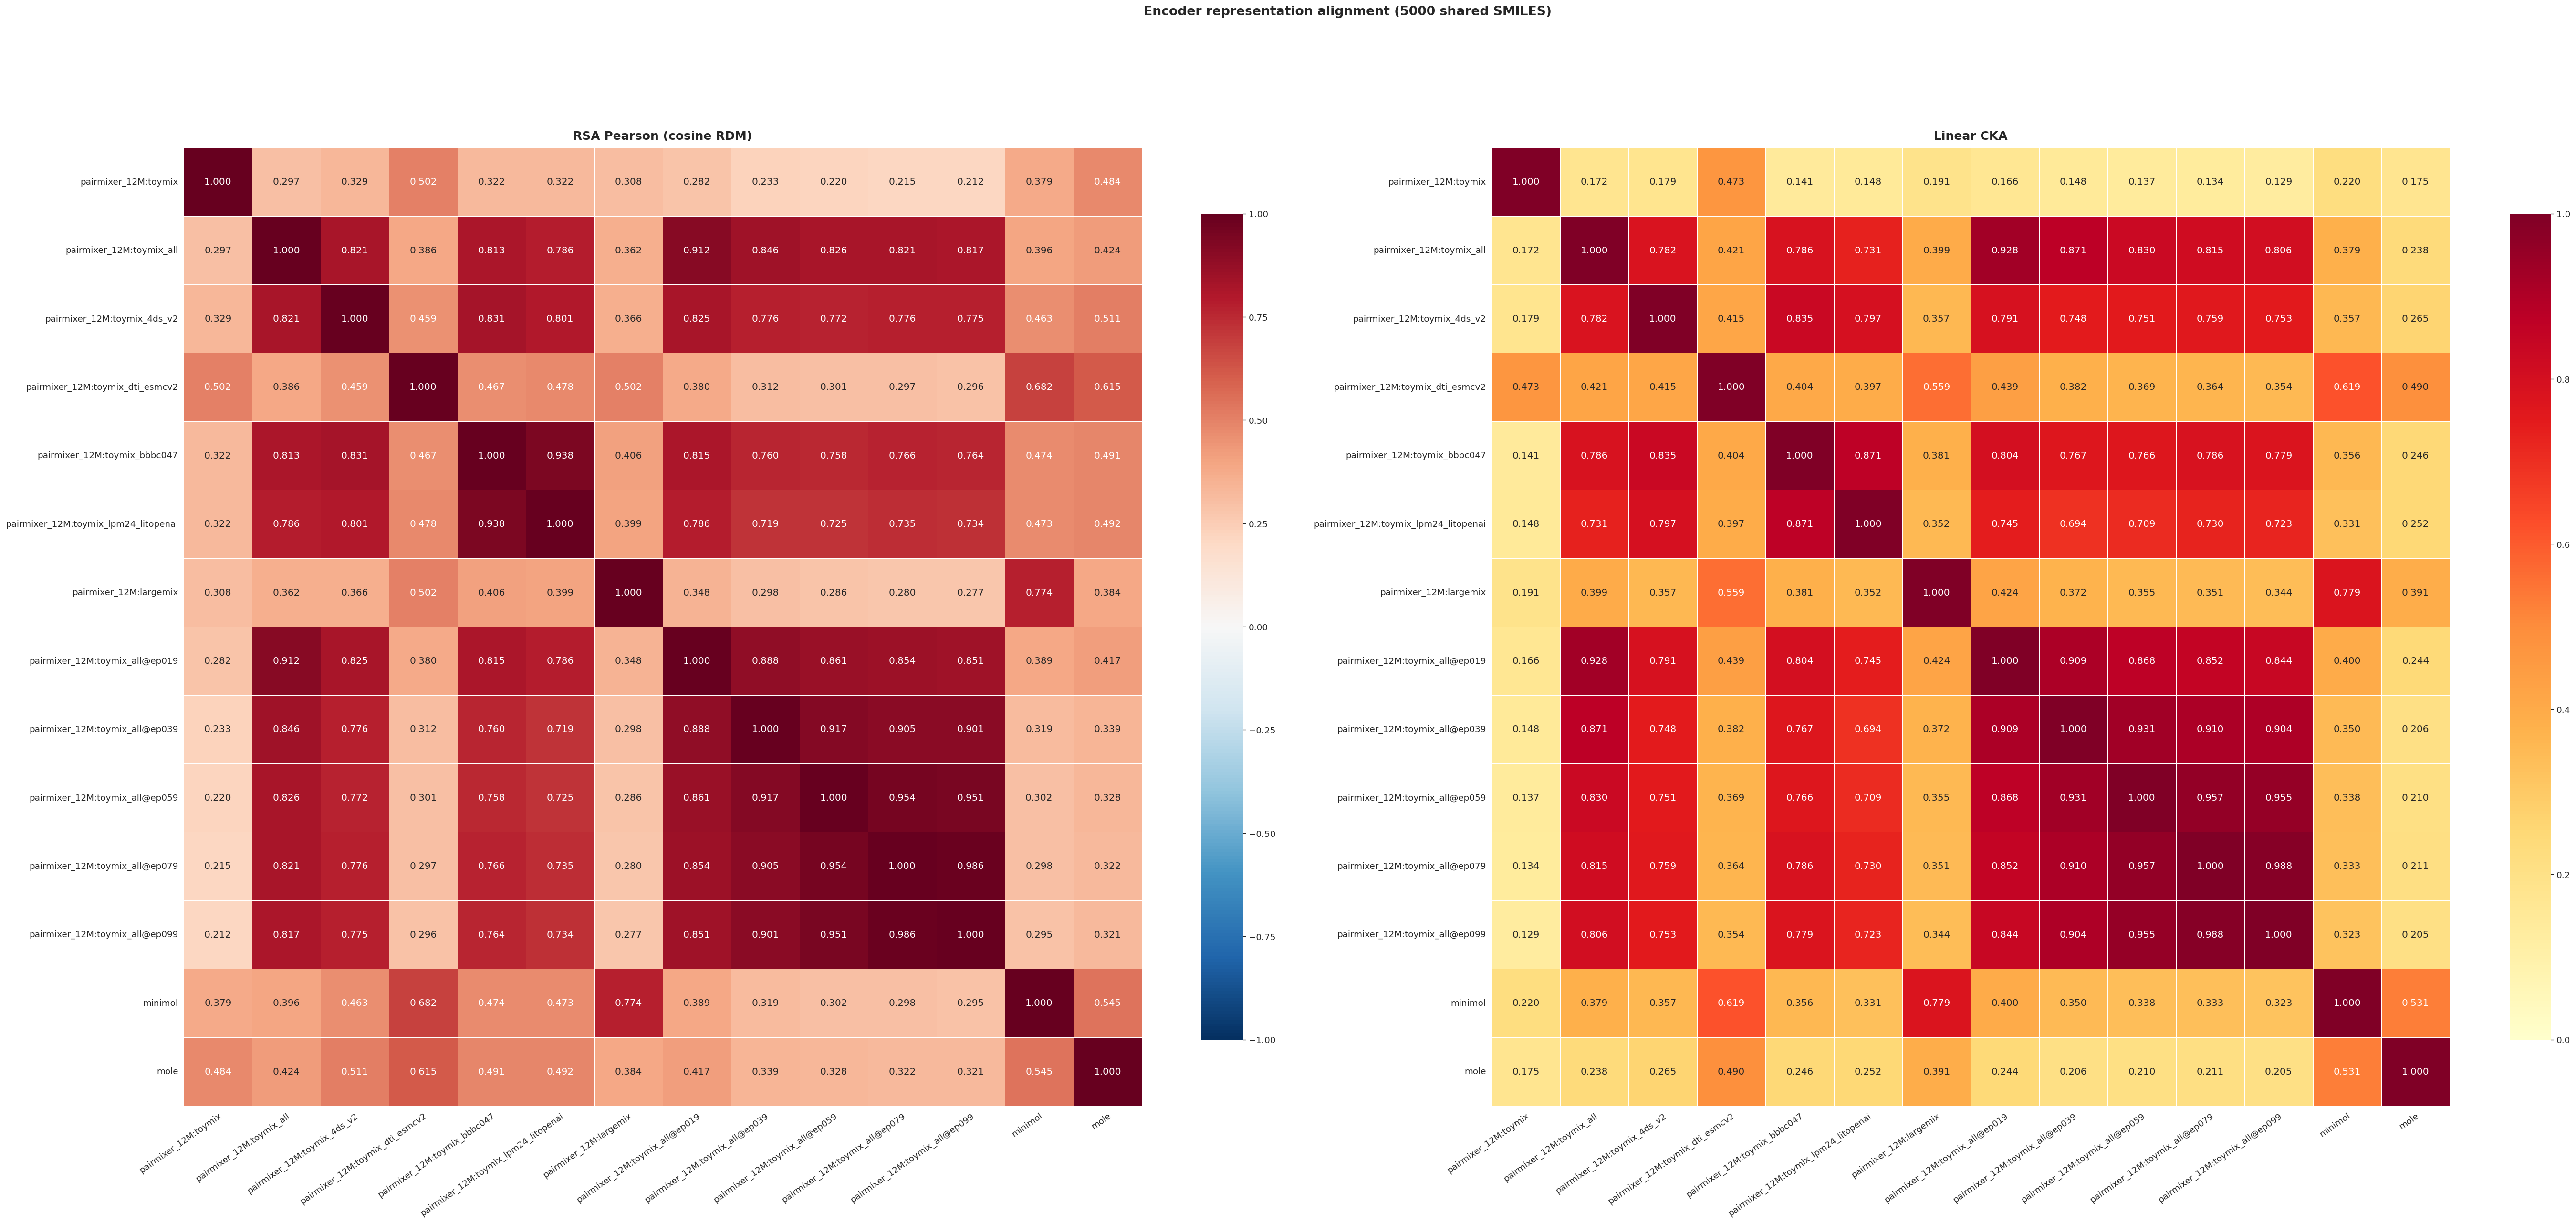

In [7]:
cell_in = 1.4  # inches per encoder cell — drives both width and height
fig_w = max(20, 2 * (cell_in * n + 4))
fig_h = max(8,  cell_in * n + 2)
fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h))

for ax, mat, title, cmap, vmin in [
    (axes[0], rsa_df, "RSA Pearson (cosine RDM)", "RdBu_r", -1.0),
    (axes[1], cka_df, "Linear CKA",                "YlOrRd",  0.0),
]:
    sns.heatmap(
        mat, ax=ax, annot=True, fmt=".3f", cmap=cmap,
        vmin=vmin, vmax=1.0, square=True,
        linewidths=0.5, linecolor="white", annot_kws={"fontsize": 12},
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(title, fontweight="bold", fontsize=15, pad=10)
    ax.tick_params(axis="x", rotation=35, labelsize=11)
    ax.tick_params(axis="y", rotation=0,  labelsize=11)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

fig.suptitle(
    f"Encoder representation alignment ({len(common)} shared SMILES)",
    fontweight="bold", fontsize=16, y=1.0,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "alignment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Focus: each encoder vs MiniMol

Headline numbers — Pearson correlation between MiniMol and every other encoder.
This notebook compares the last legacy PairMixer 12M `toymix_all` cache
against the newer `toymix_4ds_v2` snapshot as separate comparison points.

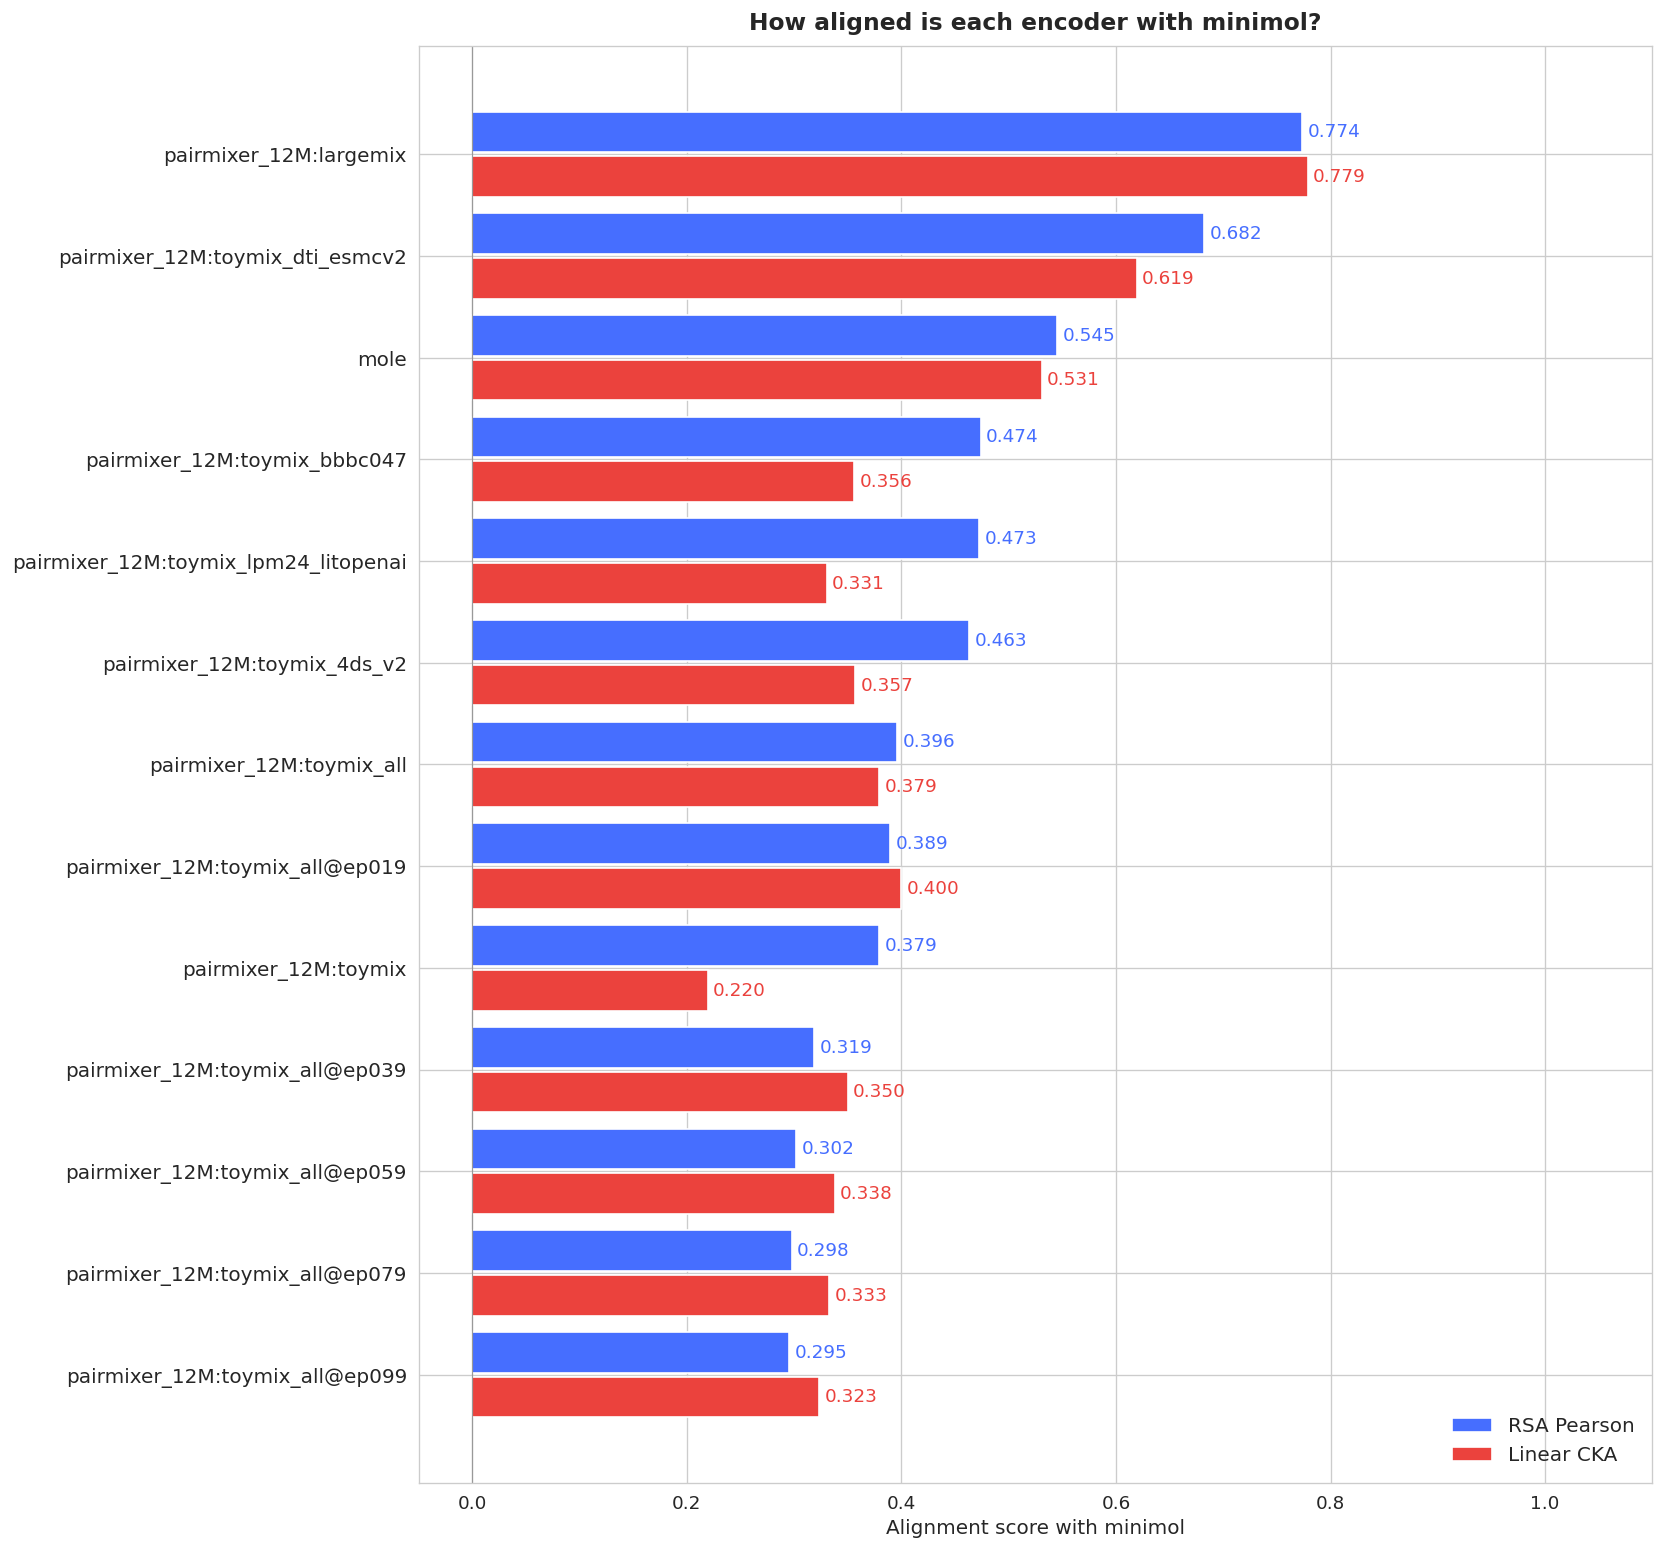

,encoder,rsa_pearson,linear_cka
0,pairmixer_12M:largemix,0.773524,0.778892
1,pairmixer_12M:toymix_dti_esmcv2,0.681986,0.619210
2,mole,0.545462,0.530908
3,pairmixer_12M:toymix_bbbc047,0.473818,0.356244
4,pairmixer_12M:toymix_lpm24_litopenai,0.472524,0.330559
5,pairmixer_12M:toymix_4ds_v2,0.463381,0.356890
6,pairmixer_12M:toymix_all,0.396349,0.379208
7,pairmixer_12M:toymix_all@ep019,0.389347,0.399928
8,pairmixer_12M:toymix,0.379134,0.219616
9,pairmixer_12M:toymix_all@ep039,0.318811,0.349895


In [8]:
PM_REF = "minimol"
if PM_REF not in rsa_df.index:
    raise KeyError(f"{PM_REF} not loaded — check baseline-extract cell above")

others = [c for c in rsa_df.index if c != PM_REF]
summary = pd.DataFrame({
    "encoder":      others,
    "rsa_pearson":  [rsa_df.loc[PM_REF, o] for o in others],
    "linear_cka":   [cka_df.loc[PM_REF, o] for o in others],
}).sort_values("rsa_pearson", ascending=False).reset_index(drop=True)
summary.to_csv(OUT_DIR / f"summary_{PM_REF.replace(':', '_')}.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 0.85 * len(others) + 2.0))
y = np.arange(len(summary))
bar_h = 0.4
ax.barh(y - 0.22, summary["rsa_pearson"], height=bar_h, label="RSA Pearson", color="#466eff")
ax.barh(y + 0.22, summary["linear_cka"],  height=bar_h, label="Linear CKA",   color="#EB423D")

# Value labels at bar tips so the numbers never get cropped by the y-tick labels.
for yi, v in zip(y - 0.22, summary["rsa_pearson"]):
    ax.text(v + 0.005, yi, f"{v:.3f}", va="center", ha="left", fontsize=11, color="#466eff")
for yi, v in zip(y + 0.22, summary["linear_cka"]):
    ax.text(v + 0.005, yi, f"{v:.3f}", va="center", ha="left", fontsize=11, color="#EB423D")

ax.set_yticks(y)
ax.set_yticklabels(summary["encoder"], fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.invert_yaxis()
ax.axvline(0, color="#999", linewidth=0.7)
ax.set_xlabel(f"Alignment score with {PM_REF}", fontsize=12)
xmin = min(0, summary[["rsa_pearson", "linear_cka"]].min().min()) - 0.05
ax.set_xlim(xmin, 1.10)  # extra headroom for the value labels
ax.legend(loc="lower right", frameon=False, fontsize=12)
ax.set_title(f"How aligned is each encoder with {PM_REF}?",
             fontweight="bold", fontsize=14, pad=10)
fig.tight_layout()
fig.savefig(OUT_DIR / f"alignment_vs_{PM_REF.replace(':', '_')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

summary